# Preliminary molecular-property data analysis

This notebook performs reproducible exploratory analysis of the supplied molecular dataset. The main target is the HOMO–LUMO gap (`gap`, eV); no predictive models are trained.

## 1. Setup

In [1]:
from collections import Counter
from pathlib import Path
import json
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold
from sklearn.decomposition import PCA

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

# Work both from the repository root and from notebooks/.
ROOT = Path.cwd()
if not (ROOT / "datasets" / "base.csv").exists():
    ROOT = ROOT.parent
if not (ROOT / "datasets" / "base.csv").exists():
    raise FileNotFoundError("Run this notebook from the repository root or notebooks/.")
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "src"))  # supports the repository's current src/ layout

from loaders import mol_json_to_fingerprint, mol_json_to_graph

DATA_PATH = ROOT / "datasets" / "base.csv"
FIGURE_DIR = ROOT / "outputs" / "figures" / "eda"
TABLE_DIR = ROOT / "outputs" / "tables"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use("default")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25})

def savefig(name):
    path = FIGURE_DIR / f"{name}.png"
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()
    return path.relative_to(ROOT)

def labeled(frame, columns):
    return frame.loc[:, columns].replace([np.inf, -np.inf], np.nan).dropna()

df = pd.read_csv(DATA_PATH)
if "mol_id" not in df and str(df.columns[0]).startswith("Unnamed"):
    df = df.rename(columns={df.columns[0]: "mol_id"})
required = {"mol_id", "json_conformer", "gap"}
missing_required = required.difference(df.columns)
assert not missing_required, f"Missing required columns: {sorted(missing_required)}"
print(f"Loaded {len(df):,} molecules from {DATA_PATH.relative_to(ROOT)}")

Loaded 116,492 molecules from datasets/base.csv


## 2. Dataset overview

In [2]:
overview = pd.DataFrame({
    "value": [
        df.shape,
        int(df.duplicated().sum()),
        int(df["mol_id"].duplicated().sum()),
        f"{df.memory_usage(deep=True).sum() / 2**20:,.1f} MiB",
    ]
}, index=["shape", "duplicate_rows", "duplicate_mol_ids", "memory_usage"])
display(overview)
display(pd.DataFrame({"dtype": df.dtypes.astype(str), "missing": df.isna().sum(),
                      "missing_pct": 100 * df.isna().mean()}))

numeric_cols = df.select_dtypes(include=np.number).columns
numerical_summary = df[numeric_cols].describe().T
numerical_summary["missing"] = df[numeric_cols].isna().sum()
numerical_summary.to_csv(TABLE_DIR / "numerical_summary.csv")
display(numerical_summary)

,value
shape,"(116492, 22)"
duplicate_rows,0
duplicate_mol_ids,0
memory_usage,176.0 MiB


,dtype,missing,missing_pct
mol_id,int64,0,0.000000
json_conformer,str,0,0.000000
A,float64,0,0.000000
B,float64,0,0.000000
C,float64,0,0.000000
mu,float64,0,0.000000
alpha,float64,0,0.000000
homo,float64,62653,53.783092
lumo,float64,62653,53.783092
gap,float64,59356,50.952855


,count,mean,std,min,25%,50%,75%,max,missing
mol_id,116492.0,58245.500000,33628.488116,0.000000,29122.750000,58245.500000,87368.250000,116491.000000,0
A,116492.0,10.767531,1939.849624,0.000000,2.553898,3.087225,3.832250,619867.683140,0
B,116492.0,1.405823,1.685024,0.337120,1.090937,1.369010,1.652763,437.903860,0
C,116492.0,1.126199,1.162772,0.331180,0.910145,1.080255,1.280482,282.945450,0
mu,116492.0,2.678558,1.505409,0.000000,1.577600,2.485350,3.607225,25.202200,0
alpha,116492.0,75.304935,8.177420,6.310000,70.510000,75.630000,80.630000,143.530000,0
homo,53839.0,-0.244585,0.319790,-26.660000,-0.252800,-0.241200,-0.228800,-0.117700,62653
lumo,53839.0,0.011668,0.063248,-5.600000,-0.023000,0.012300,0.049800,2.900000,62653
gap,57136.0,0.256125,0.345281,0.062300,0.216900,0.249700,0.288600,34.290000,59356
r2,116492.0,1190.710867,280.849563,19.000200,1018.832250,1148.132750,1310.453250,3374.753200,0


## 3. Target analysis

Only non-missing target values are used below. Outliers are identified descriptively and retained.

,gap_eV
count,57136.000000
mean,0.256125
std,0.345281
min,0.062300
25%,0.216900
50%,0.249700
75%,0.288600
max,34.290000
skewness,80.615555
IQR_outliers,42.000000


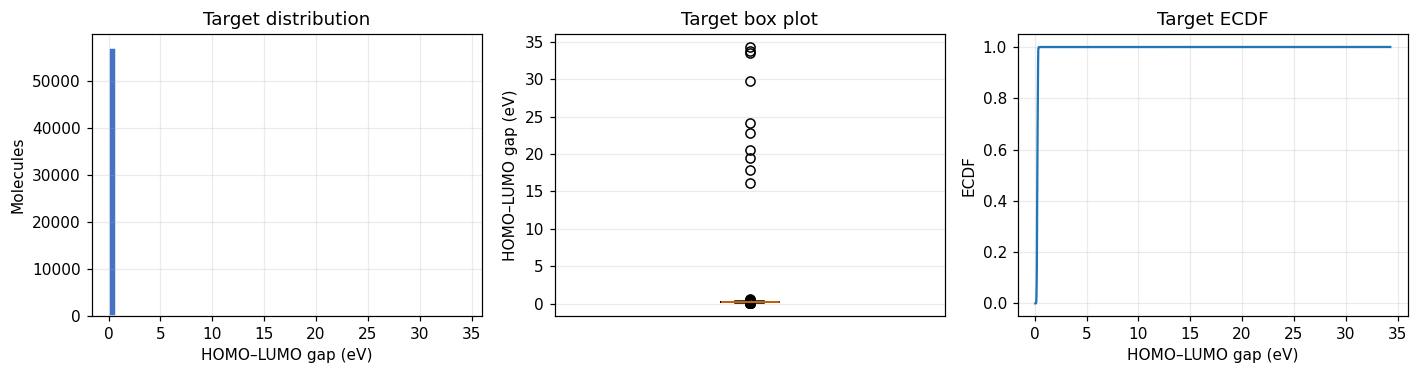

PosixPath('outputs/figures/eda/target_distribution.png')

In [3]:
gap = df["gap"].dropna()
q1, q3 = gap.quantile([0.25, 0.75])
iqr = q3 - q1
outlier_count = int(((gap < q1 - 1.5 * iqr) | (gap > q3 + 1.5 * iqr)).sum())
target_summary = gap.describe().to_frame("gap_eV")
target_summary.loc["skewness"] = gap.skew()
target_summary.loc["IQR_outliers"] = outlier_count
display(target_summary)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
axes[0].hist(gap, bins=50, color="#4472C4", edgecolor="white")
axes[0].set(xlabel="HOMO–LUMO gap (eV)", ylabel="Molecules", title="Target distribution")
axes[1].boxplot(gap, vert=True)
axes[1].set(ylabel="HOMO–LUMO gap (eV)", xticks=[], title="Target box plot")
x = np.sort(gap.to_numpy())
axes[2].plot(x, np.arange(1, len(x) + 1) / len(x))
axes[2].set(xlabel="HOMO–LUMO gap (eV)", ylabel="ECDF", title="Target ECDF")
savefig("target_distribution")

## 4. Molecular metadata

The supplied graph loader is used for every molecule. The helper validates coordinates and accepts bonds in either `(M, 2)` or documented `(2, M)` form.

In [4]:
def normalize_bonds(bonds, n_atoms):
    bonds = np.asarray(bonds)
    if bonds.size == 0:
        return np.empty((0, 2), dtype=int)
    if bonds.ndim != 2:
        raise ValueError(f"Bond array must be 2D, got {bonds.shape}")
    if bonds.shape[1] == 2:
        pairs = bonds
    elif bonds.shape[0] == 2:
        pairs = bonds.T
    else:
        raise ValueError(f"Bond array must have shape (M, 2) or (2, M), got {bonds.shape}")
    pairs = pairs.astype(int, copy=False)
    if pairs.min() < 0 or pairs.max() >= n_atoms:
        raise ValueError("Bond index outside atom range")
    return pairs

def graph_metadata(graph):
    atoms = np.asarray(graph.atom_types)
    xyz = np.asarray(graph.positions, dtype=float)
    if atoms.ndim != 1 or xyz.shape != (len(atoms), 3):
        raise ValueError(f"Invalid atom/coordinate shapes: {atoms.shape}, {xyz.shape}")
    if not np.isfinite(xyz).all():
        raise ValueError("Non-finite coordinates")
    bonds = normalize_bonds(graph.bonds, len(atoms))
    bond_types = np.asarray(graph.bond_types, dtype=float).reshape(-1)
    if len(bond_types) != len(bonds):
        raise ValueError("Bond and bond-type counts disagree")

    centered = xyz - xyz.mean(axis=0)
    distances = np.linalg.norm(centered, axis=1)
    if len(xyz) > 1:
        pairwise = np.linalg.norm(xyz[:, None, :] - xyz[None, :, :], axis=2)
        max_distance = float(pairwise.max())
        covariance = centered.T @ centered / len(xyz)
    else:
        max_distance = 0.0
        covariance = np.zeros((3, 3))
    lengths = np.linalg.norm(xyz[bonds[:, 0]] - xyz[bonds[:, 1]], axis=1) if len(bonds) else np.array([])
    row = {
        "n_atoms": len(atoms),
        "n_heavy_atoms": int(np.sum(atoms != "H")),
        "n_bonds": len(bonds),
        "n_atom_types": len(np.unique(atoms)),
        "mean_bond_length": float(lengths.mean()) if len(lengths) else np.nan,
        "std_bond_length": float(lengths.std()) if len(lengths) else np.nan,
        "radius_of_gyration": float(np.sqrt(np.mean(distances ** 2))),
        "max_atomic_distance": max_distance,
    }
    row.update({f"element_{k}": v for k, v in Counter(atoms).items()})
    row.update({f"bond_type_{k:g}": v for k, v in Counter(bond_types).items()})
    for i, value in enumerate(np.linalg.eigvalsh(covariance), 1):
        row[f"coordinate_cov_eigenvalue_{i}"] = float(value)
    return row

graphs = mol_json_to_graph(df["json_conformer"].tolist(), n_jobs=1)
metadata = pd.DataFrame.from_records([graph_metadata(graph) for graph in graphs]).fillna(
    {c: 0 for c in []}
)
count_cols = [c for c in metadata if c.startswith(("element_", "bond_type_"))]
metadata[count_cols] = metadata[count_cols].fillna(0).astype(int)
metadata.insert(0, "mol_id", df["mol_id"].to_numpy())
metadata.to_csv(TABLE_DIR / "molecular_metadata.csv", index=False)
display(metadata.describe().T)

,count,mean,std,min,25%,50%,75%,max
mol_id,116492.0,58245.500000,33628.488116,0.000000e+00,29122.750000,58245.500000,87368.250000,116491.000000
n_atoms,116492.0,18.038037,2.947248,3.000000e+00,16.000000,18.000000,20.000000,29.000000
n_heavy_atoms,116492.0,8.795686,0.509485,1.000000e+00,9.000000,9.000000,9.000000,9.000000
n_bonds,116492.0,18.645830,3.148413,2.000000e+00,17.000000,19.000000,21.000000,28.000000
n_atom_types,116492.0,3.477715,0.582537,2.000000e+00,3.000000,4.000000,4.000000,5.000000
mean_bond_length,116492.0,1.268875,0.028262,9.621082e-01,1.247799,1.267044,1.287199,1.395782
std_bond_length,116492.0,0.194571,0.020456,1.643714e-05,0.183373,0.198302,0.209287,0.251627
radius_of_gyration,116492.0,2.393280,0.237795,6.783531e-01,2.237061,2.360748,2.510186,4.291862
max_atomic_distance,116492.0,6.543066,0.980201,1.513328e+00,5.809582,6.415088,7.054141,12.040427
element_O,116492.0,1.398002,0.885041,0.000000e+00,1.000000,1.000000,2.000000,5.000000


## 5. Molecular composition and geometry

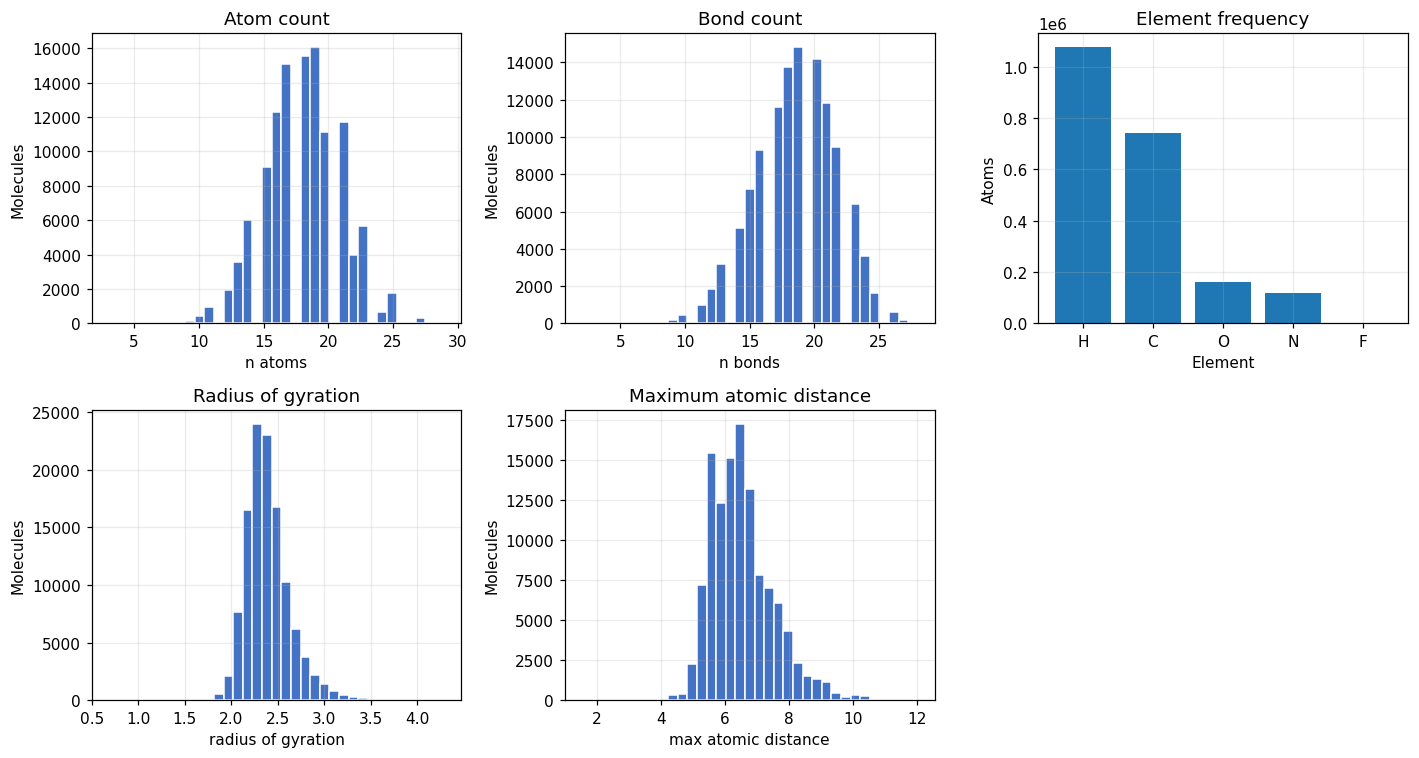

,pearson,spearman
n_bonds,0.085470,0.587862
n_atoms,0.080669,0.547096
radius_of_gyration,0.009686,0.071511
n_heavy_atoms,-0.011172,-0.065114
max_atomic_distance,0.006619,0.045026


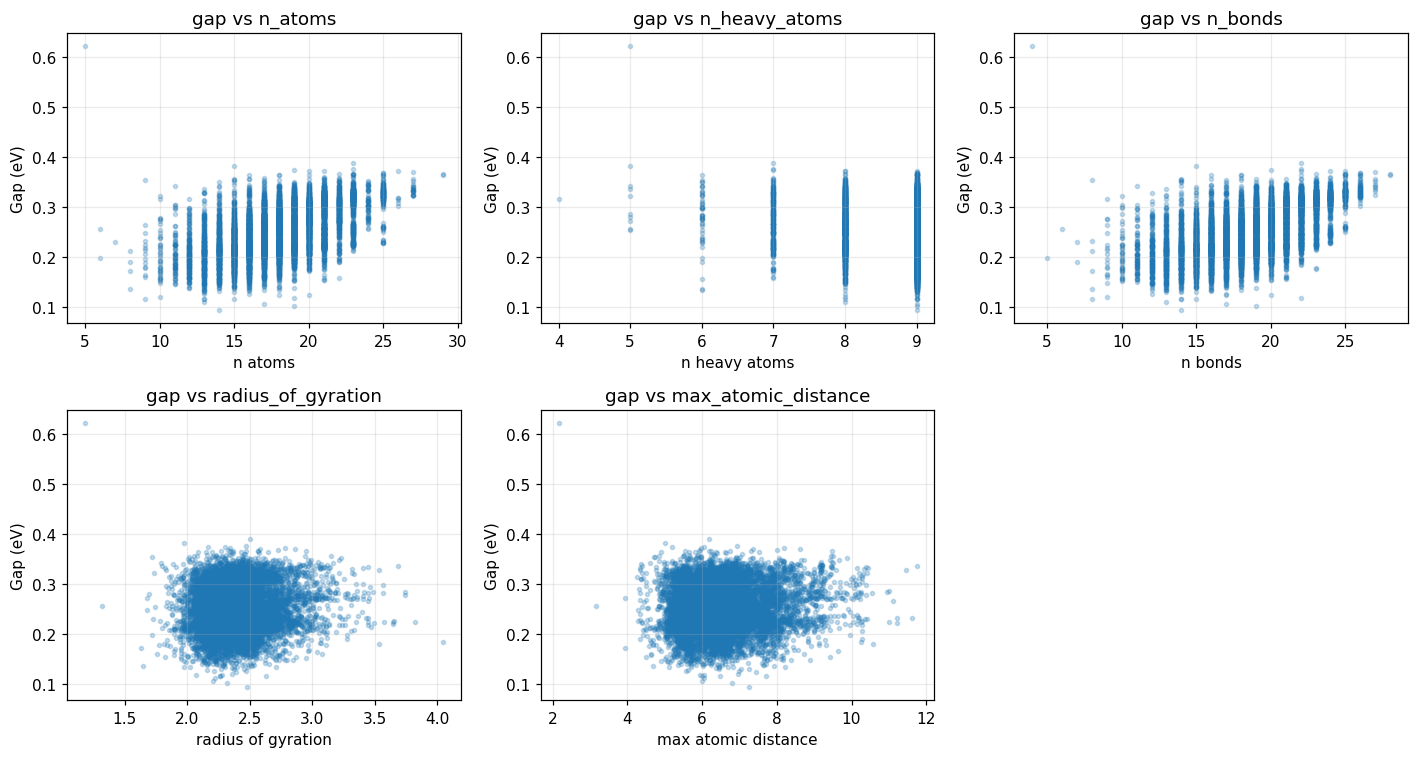

PosixPath('outputs/figures/eda/gap_vs_structural_descriptors.png')

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, column, title in [
    (axes[0, 0], "n_atoms", "Atom count"),
    (axes[0, 1], "n_bonds", "Bond count"),
    (axes[1, 0], "radius_of_gyration", "Radius of gyration"),
    (axes[1, 1], "max_atomic_distance", "Maximum atomic distance"),
]:
    ax.hist(metadata[column], bins=35, color="#4472C4", edgecolor="white")
    ax.set(title=title, xlabel=column.replace("_", " "), ylabel="Molecules")
element_totals = metadata.filter(like="element_").sum().sort_values(ascending=False)
axes[0, 2].bar(element_totals.index.str.replace("element_", ""), element_totals.values)
axes[0, 2].set(title="Element frequency", xlabel="Element", ylabel="Atoms")
axes[1, 2].axis("off")
savefig("composition_and_geometry")

descriptor_cols = ["n_atoms", "n_heavy_atoms", "n_bonds", "radius_of_gyration", "max_atomic_distance"]
analysis = metadata.set_index("mol_id")[descriptor_cols].join(df.set_index("mol_id")["gap"])
descriptor_correlations = pd.DataFrame({
    "pearson": analysis.corr(method="pearson")["gap"].drop("gap"),
    "spearman": analysis.corr(method="spearman")["gap"].drop("gap"),
}).sort_values("spearman", key=abs, ascending=False)
display(descriptor_correlations)

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
plot_data = analysis.dropna(subset=["gap"])
plot_data = plot_data.sample(min(10_000, len(plot_data)), random_state=RANDOM_STATE)
for ax, column in zip(axes.flat, descriptor_cols):
    ax.scatter(plot_data[column], plot_data["gap"], s=7, alpha=0.25)
    ax.set(xlabel=column.replace("_", " "), ylabel="Gap (eV)", title=f"gap vs {column}")
axes.flat[-1].axis("off")
savefig("gap_vs_structural_descriptors")

## 6. Other molecular properties

Correlations among supplied numerical properties are descriptive. `homo`, `lumo`, and other target columns are outcomes, not ordinary predictive inputs: using them can leak target information.

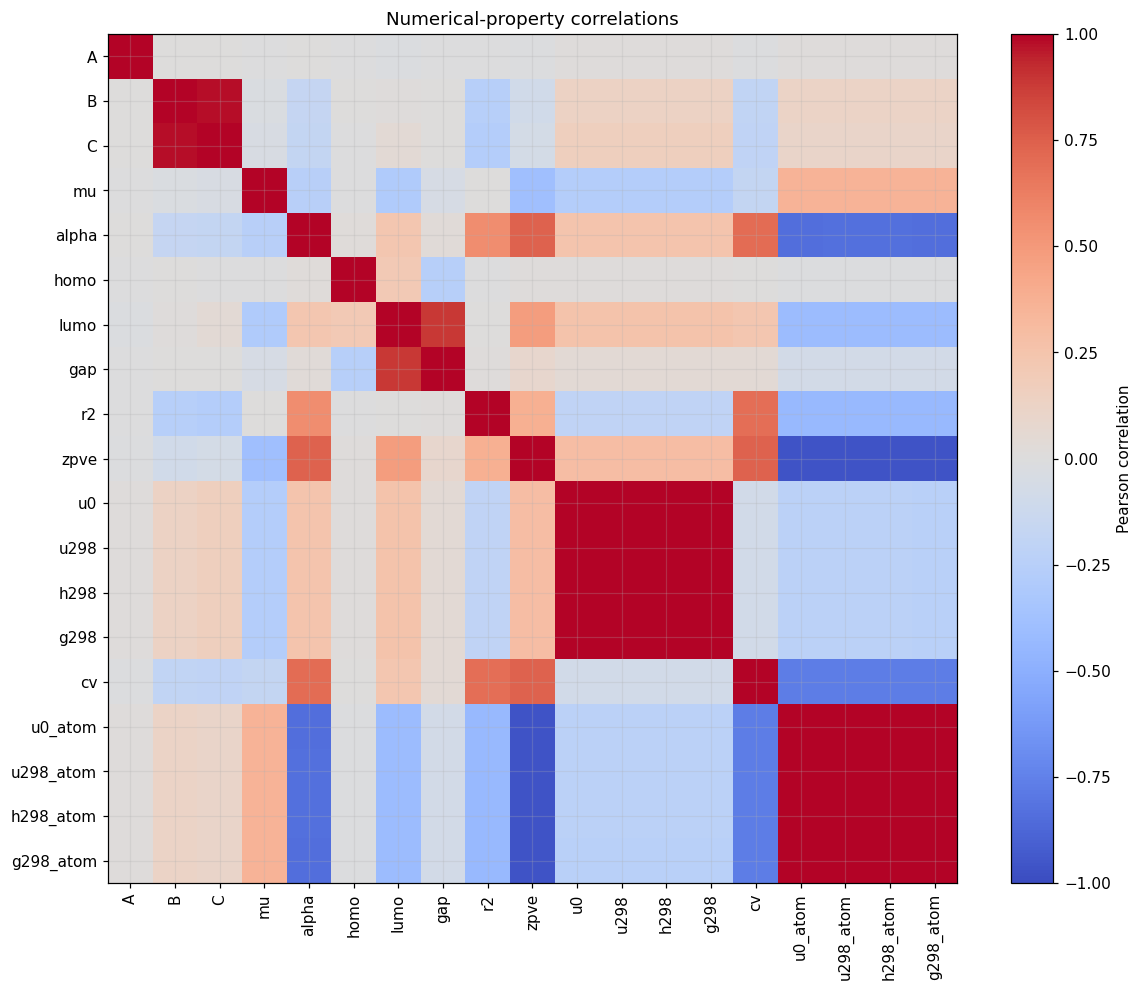

,pearson,spearman
lumo,0.888640,0.890110
homo,-0.257688,-0.229580
zpve,0.084586,0.569994
h298_atom,-0.072756,-0.488156
u298_atom,-0.072687,-0.487675
u0_atom,-0.072520,-0.486538
g298_atom,-0.071772,-0.480736
mu,-0.052073,-0.320326
cv,0.043118,0.308822
u298,0.039655,0.248417


Rows with all orbital values: 17,567
Mean absolute residual |gap - (lumo - homo)|: 2.47737e-05 eV
Maximum absolute residual: 0.0001 eV


In [6]:
property_numeric = df.select_dtypes(include=np.number).drop(columns=["mol_id"], errors="ignore")
corr = property_numeric.corr()
fig, ax = plt.subplots(figsize=(11, 9))
image = ax.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
ax.set(xticks=range(len(corr)), yticks=range(len(corr)),
       xticklabels=corr.columns, yticklabels=corr.index, title="Numerical-property correlations")
plt.setp(ax.get_xticklabels(), rotation=90)
fig.colorbar(image, ax=ax, label="Pearson correlation")
savefig("numerical_correlation_heatmap")

target_correlations = pd.DataFrame({
    "pearson": property_numeric.corr(method="pearson")["gap"].drop("gap"),
    "spearman": property_numeric.corr(method="spearman")["gap"].drop("gap"),
}).sort_values("pearson", key=abs, ascending=False)
target_correlations.to_csv(TABLE_DIR / "target_correlations.csv")
display(target_correlations)

orbital = labeled(df, ["gap", "lumo", "homo"])
orbital_residual = orbital["gap"] - (orbital["lumo"] - orbital["homo"])
print(f"Rows with all orbital values: {len(orbital):,}")
print(f"Mean absolute residual |gap - (lumo - homo)|: {orbital_residual.abs().mean():.6g} eV")
print(f"Maximum absolute residual: {orbital_residual.abs().max():.6g} eV")

## 7. Morgan fingerprints

{'shape': (116492, 2048), 'overall_density': 0.009945157178175325, 'unused_bits': 0, 'duplicate_fingerprints': 658}


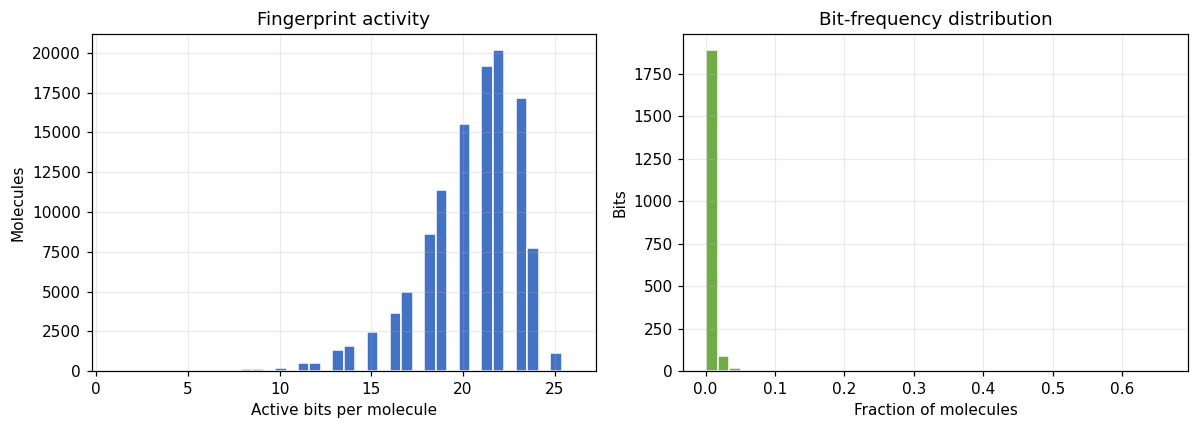

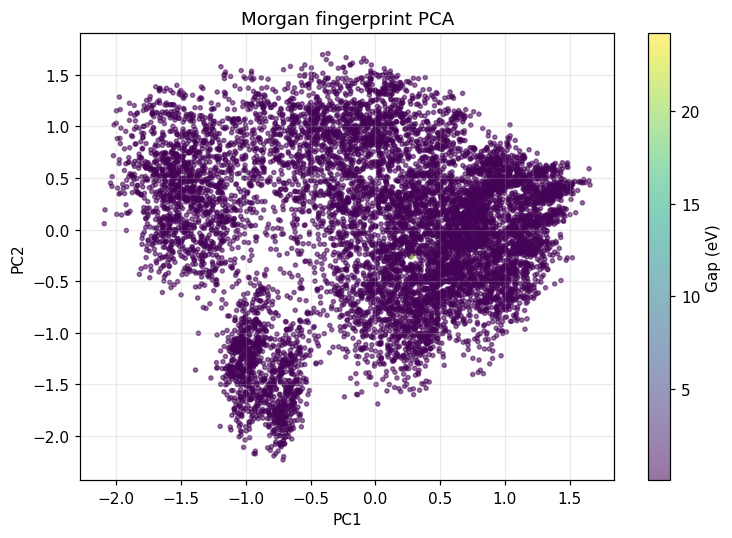

PosixPath('outputs/figures/eda/fingerprint_pca.png')

In [7]:
fingerprints = mol_json_to_fingerprint(
    df["json_conformer"],
    radius=2,
    n_bits=2048,
)
active_bits = fingerprints.sum(axis=1)
bit_frequency = fingerprints.mean(axis=0)
packed = np.packbits(fingerprints, axis=1)
duplicate_fingerprints = int(pd.DataFrame(packed).duplicated().sum())
print({
    "shape": fingerprints.shape,
    "overall_density": float(fingerprints.mean()),
    "unused_bits": int((bit_frequency == 0).sum()),
    "duplicate_fingerprints": duplicate_fingerprints,
})

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(active_bits, bins=40, color="#4472C4", edgecolor="white")
axes[0].set(xlabel="Active bits per molecule", ylabel="Molecules", title="Fingerprint activity")
axes[1].hist(bit_frequency, bins=40, color="#70AD47", edgecolor="white")
axes[1].set(xlabel="Fraction of molecules", ylabel="Bits", title="Bit-frequency distribution")
savefig("fingerprint_sparsity")

pca_pool = np.flatnonzero(df["gap"].notna().to_numpy())
pca_idx = rng.choice(pca_pool, size=min(10_000, len(pca_pool)), replace=False)
pca_xy = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(fingerprints[pca_idx])
plt.figure(figsize=(7, 5))
scatter = plt.scatter(pca_xy[:, 0], pca_xy[:, 1], c=df["gap"].to_numpy()[pca_idx],
                      s=7, alpha=0.55, cmap="viridis")
plt.colorbar(scatter, label="Gap (eV)")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.title("Morgan fingerprint PCA")
savefig("fingerprint_pca")

## 8. Molecular similarity

Pairwise Tanimoto similarity is computed only on a fixed labeled sample; this avoids a full quadratic matrix.

,similarity_bin,pair_count,median_absolute_gap_difference_eV
0,"[0.0, 0.1)",228183,0.0517
1,"[0.1, 0.2)",84034,0.0391
2,"[0.2, 0.3)",6848,0.0256
3,"[0.3, 0.4)",465,0.0196
4,"[0.4, 0.5)",55,0.0169
5,"[0.5, 0.6)",13,0.0164
6,"[0.6, 0.7)",1,0.0040
7,"[0.7, 0.8)",0,NaN
8,"[0.8, 0.9)",1,0.0004
9,"[0.9, 1.0)",0,NaN


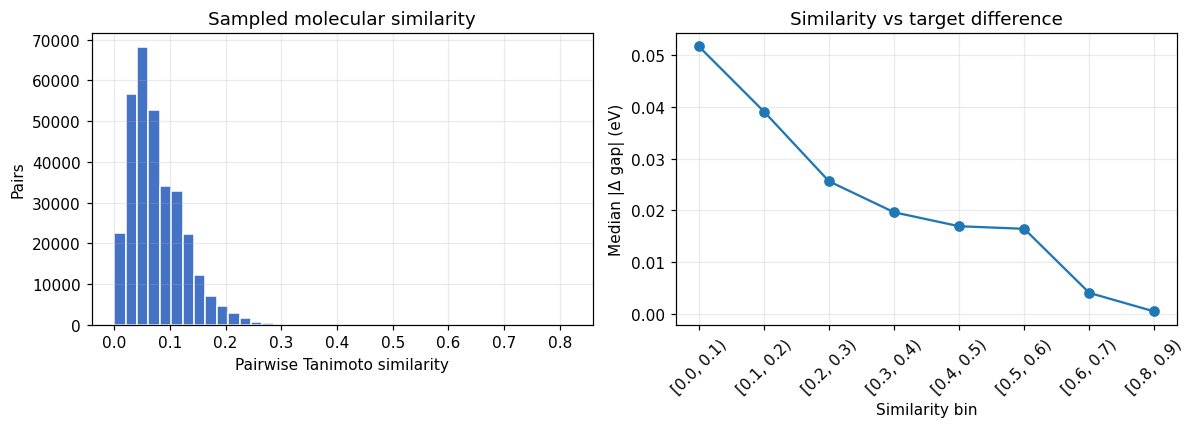

PosixPath('outputs/figures/eda/similarity_and_gap_difference.png')

In [8]:
similarity_idx = rng.choice(np.flatnonzero(df["gap"].notna().to_numpy()),
                            size=min(800, df["gap"].notna().sum()), replace=False)
sample_fp = fingerprints[similarity_idx].astype(np.int32)
sample_gap = df["gap"].to_numpy()[similarity_idx]
similarities, gap_differences = [], []
for i in range(len(sample_fp) - 1):
    intersection = sample_fp[i + 1:] @ sample_fp[i]
    union = sample_fp[i + 1:].sum(axis=1) + sample_fp[i].sum() - intersection
    similarities.append(intersection / np.maximum(union, 1))
    gap_differences.append(np.abs(sample_gap[i + 1:] - sample_gap[i]))
similarities = np.concatenate(similarities)
gap_differences = np.concatenate(gap_differences)

bins = np.array([0, .1, .2, .3, .4, .5, .6, .7, .8, .9, 1.000001])
similarity_bin = pd.cut(similarities, bins=bins, right=False)
similarity_table = (
    pd.DataFrame({"similarity_bin": similarity_bin, "absolute_gap_difference_eV": gap_differences})
    .groupby("similarity_bin", observed=False)["absolute_gap_difference_eV"]
    .agg(pair_count="size", median_absolute_gap_difference_eV="median")
    .reset_index()
)
similarity_table["similarity_bin"] = similarity_table["similarity_bin"].astype(str)
similarity_table.to_csv(TABLE_DIR / "similarity_vs_gap_difference.csv", index=False)
display(similarity_table)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(similarities, bins=40, color="#4472C4", edgecolor="white")
axes[0].set(xlabel="Pairwise Tanimoto similarity", ylabel="Pairs", title="Sampled molecular similarity")
valid_bins = similarity_table["pair_count"] > 0
axes[1].plot(similarity_table.loc[valid_bins, "similarity_bin"],
             similarity_table.loc[valid_bins, "median_absolute_gap_difference_eV"], marker="o")
axes[1].tick_params(axis="x", rotation=45)
axes[1].set(xlabel="Similarity bin", ylabel="Median |Δ gap| (eV)", title="Similarity vs target difference")
savefig("similarity_and_gap_difference")

## 9. Scaffold analysis

Bemis–Murcko scaffolds group molecules by core structure. Their frequency profile motivates comparing random splits with scaffold splits later: the latter better tests transfer to unseen cores.

,metric,value
0,unique_scaffolds,35420.000000
1,singleton_scaffolds,26404.000000
2,empty_scaffold_proportion,0.103269
3,top_10_molecule_percentage,19.131786


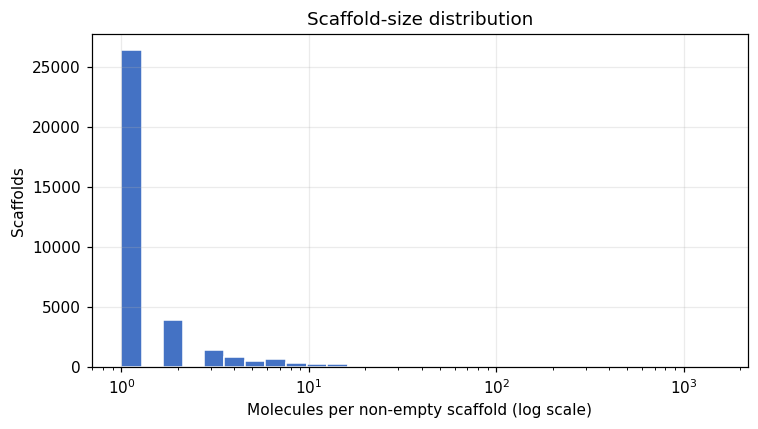

PosixPath('outputs/figures/eda/scaffold_size_distribution.png')

In [9]:
def scaffold_smiles(js):
    mol = Chem.JSONToMols(js)[0]
    return Chem.MolToSmiles(MurckoScaffold.GetScaffoldForMol(Chem.RemoveHs(mol)), canonical=True)

scaffolds = pd.Series([scaffold_smiles(js) for js in df["json_conformer"]], name="scaffold")
scaffold_counts = scaffolds.value_counts(dropna=False)
nonempty_counts = scaffold_counts.drop(index="", errors="ignore")
scaffold_summary = pd.DataFrame({
    "metric": ["unique_scaffolds", "singleton_scaffolds", "empty_scaffold_proportion",
               "top_10_molecule_percentage"],
    "value": [scaffolds.nunique(), int((nonempty_counts == 1).sum()),
              float((scaffolds == "").mean()), float(100 * scaffold_counts.head(10).sum() / len(scaffolds))],
})
size_distribution = scaffold_counts.value_counts().sort_index().rename_axis("molecules_per_scaffold").reset_index(name="scaffold_count")
scaffold_summary.to_csv(TABLE_DIR / "scaffold_summary.csv", index=False)
display(scaffold_summary)

plt.figure(figsize=(7, 4))
plt.hist(nonempty_counts, bins=np.logspace(0, np.log10(max(nonempty_counts.max(), 2)), 30),
         color="#4472C4", edgecolor="white")
plt.xscale("log")
plt.xlabel("Molecules per non-empty scaffold (log scale)")
plt.ylabel("Scaffolds"); plt.title("Scaffold-size distribution")
savefig("scaffold_size_distribution")

## 10. Data-quality checks

In [10]:
finite_issues = {
    c: int((~np.isfinite(df[c].dropna().to_numpy())).sum())
    for c in df.select_dtypes(include=np.number)
}
nunique = df.nunique(dropna=True)
constant = nunique[nunique <= 1].index.tolist()
near_constant = []
for c in df.columns:
    counts = df[c].value_counts(dropna=False, normalize=True)
    if len(counts) > 1 and counts.iloc[0] >= 0.99:
        near_constant.append(c)

quality_checks = pd.Series({
    "duplicate_mol_ids": int(df["mol_id"].duplicated().sum()),
    "duplicate_json_strings": int(df["json_conformer"].duplicated().sum()),
    "duplicate_fingerprints": duplicate_fingerprints,
    "numeric_non_finite_values": int(sum(finite_issues.values())),
    "constant_columns": constant,
    "nearly_constant_columns_99pct": near_constant,
    "gap_equals_lumo_minus_homo_max_abs_residual_eV":
        float(orbital_residual.abs().max()) if len(orbital_residual) else np.nan,
})
display(quality_checks.to_frame("result"))
print("Potential deterministic leakage relationship: gap = lumo - homo where all three are supplied.")

,result
duplicate_mol_ids,0
duplicate_json_strings,0
duplicate_fingerprints,658
numeric_non_finite_values,0
constant_columns,[]
nearly_constant_columns_99pct,[]
gap_equals_lumo_minus_homo_max_abs_residual_eV,0.0001


Potential deterministic leakage relationship: gap = lumo - homo where all three are supplied.


## 11. Preliminary findings and modeling implications

In [11]:
heavy_elements = element_totals.drop(labels=["element_H"], errors="ignore")
top_elements = ", ".join(heavy_elements.head(4).index.str.replace("element_", ""))
best_3d = descriptor_correlations["spearman"].abs().idxmax()
best_3d_rho = descriptor_correlations.loc[best_3d, "spearman"]
nonempty_similarity = similarity_table.loc[similarity_table["pair_count"] > 0]
similarity_trend = "decreases" if (
    nonempty_similarity["median_absolute_gap_difference_eV"].iloc[-1]
    < nonempty_similarity["median_absolute_gap_difference_eV"].iloc[0]
) else "does not decrease consistently"

display(Markdown(f'''
## Preliminary findings and modeling implications

- **Dataset quality:** {len(df):,} rows, {df["gap"].notna().sum():,} labeled targets, {int(df["mol_id"].duplicated().sum())} duplicate IDs, {int(df["json_conformer"].duplicated().sum())} duplicate molecular JSON strings, and {sum(finite_issues.values())} non-finite numerical values (excluding missing values).
- **Target distribution:** mean {gap.mean():.3f} eV, standard deviation {gap.std():.3f} eV, skewness {gap.skew():.3f}, with {outlier_count:,} IQR-flagged values retained.
- **Molecular size and composition:** median {metadata["n_atoms"].median():.0f} atoms and {metadata["n_bonds"].median():.0f} bonds; the most frequent non-hydrogen elements are {top_elements}.
- **Chemical diversity:** {scaffolds.nunique():,} unique scaffolds; {(scaffolds == "").mean():.1%} are empty/acyclic and {100 * scaffold_counts.head(10).sum() / len(scaffolds):.1f}% of molecules belong to the ten most frequent scaffold labels.
- **Fingerprint sparsity:** mean density {fingerprints.mean():.3%}, {(bit_frequency == 0).sum():,} unused bits, and {duplicate_fingerprints:,} duplicate fingerprints.
- **Similarity versus target:** median absolute target difference {similarity_trend} from the lowest to highest populated similarity bins in the reproducible sample.
- **Simple 3D descriptors:** the strongest absolute Spearman association is `{best_3d}` (ρ={best_3d_rho:.3f}); these descriptors may add geometric signal but are unlikely to capture chemistry alone.
- **Leakage risk:** `gap ≈ lumo - homo` has maximum absolute residual {orbital_residual.abs().max():.3g} eV. Orbital energies and other supplied target properties must be excluded from ordinary predictive features.
- **Later hypotheses:** compare size/geometry descriptors against connectivity fingerprints, test whether their combination adds value, and measure generalization under both random and scaffold-aware splits.

Proposed next experiments (not implemented here):

1. Constant baseline.
2. Simple molecular descriptors.
3. Morgan fingerprints with classical ML.
4. Combined 2D and 3D descriptors.
5. Optional graph or geometric neural network.
6. Random versus scaffold split.
'''))


## Preliminary findings and modeling implications

- **Dataset quality:** 116,492 rows, 57,136 labeled targets, 0 duplicate IDs, 0 duplicate molecular JSON strings, and 0 non-finite numerical values (excluding missing values).
- **Target distribution:** mean 0.256 eV, standard deviation 0.345 eV, skewness 80.616, with 42 IQR-flagged values retained.
- **Molecular size and composition:** median 18 atoms and 19 bonds; the most frequent non-hydrogen elements are C, O, N, F.
- **Chemical diversity:** 35,420 unique scaffolds; 10.3% are empty/acyclic and 19.1% of molecules belong to the ten most frequent scaffold labels.
- **Fingerprint sparsity:** mean density 0.995%, 0 unused bits, and 658 duplicate fingerprints.
- **Similarity versus target:** median absolute target difference decreases from the lowest to highest populated similarity bins in the reproducible sample.
- **Simple 3D descriptors:** the strongest absolute Spearman association is `n_bonds` (ρ=0.588); these descriptors may add geometric signal but are unlikely to capture chemistry alone.
- **Leakage risk:** `gap ≈ lumo - homo` has maximum absolute residual 0.0001 eV. Orbital energies and other supplied target properties must be excluded from ordinary predictive features.
- **Later hypotheses:** compare size/geometry descriptors against connectivity fingerprints, test whether their combination adds value, and measure generalization under both random and scaffold-aware splits.

Proposed next experiments (not implemented here):

1. Constant baseline.
2. Simple molecular descriptors.
3. Morgan fingerprints with classical ML.
4. Combined 2D and 3D descriptors.
5. Optional graph or geometric neural network.
6. Random versus scaffold split.
